### IMPORT LIBRARIES 

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### IMPORT DATA 

In [15]:
df = pd.read_excel(r"C:\Users\user\Desktop\B2B analytics Project\b2b_survey_analytics_dataset.xlsx")
df.head()

,respondent_id,company_name,industry,company_size,employee_count,country,annual_revenue_usd,survey_date,survey_duration_seconds,completion_rate,satisfaction_score,likelihood_to_buy,nps_score,free_text_response
0,RESP-100000,"Davidson, Smith and Crosby",Healthcare,1-50,39,Netherlands,30261379.60,2026-01-26,400,0.69,7.0,7,5,Pricing could be more flexible.
1,RESP-100001,Anderson-Mills,Manufacturing,1000+,5558,USA,11471483.43,2026-04-19,387,0.90,10.0,8,10,Great platform and responsive support.
2,RESP-100002,"Lane, Rodriguez and Hurley",Finance,501-1000,684,UK,8855095.73,2026-04-25,527,0.77,10.0,10,10,Very satisfied with product quality.
3,RESP-100003,Adams Ltd,Technology,501-1000,599,USA,8891645.95,2026-03-04,355,0.84,8.0,6,10,Great platform and responsive support.
4,RESP-100004,Smith-Warner,Manufacturing,201-500,390,Greece,2225552.70,2026-04-06,152,0.81,NaN,6,9,Very satisfied with product quality.


In [16]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", None)

# DATA CLEANING

In [17]:
#duplicates
df = df.drop_duplicates()

The last row of the dataframe was a duplicate that was not able to be removed. It will be removed manually

In [19]:
df = df.iloc[:-1]

### UNIQUE VALUES

In [20]:
df["industry"].unique()

array(['Healthcare', 'Manufacturing', 'Finance', 'Technology',
       'Telecommunications', 'Retail', 'Energy', 'Consulting', nan],
      dtype=object)

In [21]:
df["company_size"].unique()

array(['1-50', '1000+', '501-1000', '201-500', '51-200'], dtype=object)

In [22]:
df["country"].unique()

array(['Netherlands', 'USA', 'UK', 'Greece', 'France', 'Spain', 'Germany'],
      dtype=object)

In [23]:
df["free_text_response"].unique()

array(['Pricing could be more flexible.',
       'Great platform and responsive support.',
       'Very satisfied with product quality.',
       'Customer support response time is slow.',
       'Dashboard needs more customization.',
       'Reliable service and good account management.',
       'Excellent onboarding experience.',
       'Would like better integrations.'], dtype=object)

In [24]:
pd.DataFrame(df["company_name"].unique()).head(50)

,0
0,"Davidson, Smith and Crosby"
1,Anderson-Mills
2,"Lane, Rodriguez and Hurley"
3,Adams Ltd
4,Smith-Warner
5,Williams-Soto
6,Barker-Atkinson
7,Harris Ltd
8,Walker and Sons
9,Jackson-James


### STRIP

In [25]:
df["country"] = df["country"].str.strip()

In [26]:
df["free_text_response"] = df["free_text_response"].str.strip()

In [27]:
df["industry"] = df["industry"].str.strip()

### REMOVE '-'

In [28]:
df["company_name"] = df["company_name"].str.replace("-", " ")
df["company_name"].head()

0    Davidson, Smith and Crosby
1                Anderson Mills
2    Lane, Rodriguez and Hurley
3                     Adams Ltd
4                  Smith Warner
Name: company_name, dtype: object

### HANDLE NULL VALUES

In [29]:
df.isnull().sum()

respondent_id               0
company_name                0
industry                   25
company_size                0
employee_count              0
country                     0
annual_revenue_usd         25
survey_date                 0
survey_duration_seconds     0
completion_rate             0
satisfaction_score         25
likelihood_to_buy           0
nps_score                   0
free_text_response          0
dtype: int64

In [30]:
# industry
df.loc[df["industry"].isnull(), "industry"] = "Unknown"
df["industry"].isnull().sum()

np.int64(0)

In [31]:
# satisfaction_score
df.loc[(df["satisfaction_score"].isnull()) & (df["nps_score"] >= 7), "satisfaction_score"] = 8.0
df.loc[(df["satisfaction_score"].isnull()) & (df["nps_score"] < 7), "satisfaction_score"] = 5.5
df["satisfaction_score"].isnull().sum()

np.int64(0)

In [32]:
# revenue
df.loc[df["annual_revenue_usd"].isnull(), "annual_revenue_usd"] = df["annual_revenue_usd"].mean()

### FILTERING AND RESET INDEX

In [71]:
df = df.reset_index(drop = "True")

### ROUNDING IN THE COLUMN "annual_revenue_usd"

In [34]:
df["annual_revenue_usd"] = df["annual_revenue_usd"].round(0).astype(int)

# EDA (exploratory data analysis)

### INFOS AND DESCRIPTIVE STATISTICS

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   respondent_id            1200 non-null   object        
 1   company_name             1200 non-null   object        
 2   industry                 1200 non-null   object        
 3   company_size             1200 non-null   object        
 4   employee_count           1200 non-null   int64         
 5   country                  1200 non-null   object        
 6   annual_revenue_usd       1200 non-null   int64         
 7   survey_date              1200 non-null   datetime64[ns]
 8   survey_duration_seconds  1200 non-null   int64         
 9   completion_rate          1200 non-null   float64       
 10  satisfaction_score       1200 non-null   float64       
 11  likelihood_to_buy        1200 non-null   int64         
 12  nps_score                1200 non-

In [36]:
df.describe()

,employee_count,annual_revenue_usd,survey_date,survey_duration_seconds,completion_rate,satisfaction_score,likelihood_to_buy,nps_score
count,1200.000000,1.200000e+03,1200,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,1345.597500,2.836034e+07,2026-03-25 13:44:24,393.180000,0.827958,6.465833,6.399167,6.324167
min,5.000000,5.357710e+05,2026-01-26 00:00:00,4.000000,0.650000,1.000000,1.000000,0.000000
25%,92.000000,7.757754e+06,2026-02-23 18:00:00,294.750000,0.740000,5.000000,5.000000,4.000000
50%,354.000000,1.635936e+07,2026-03-25 00:00:00,406.000000,0.830000,6.000000,6.000000,6.000000
75%,908.250000,3.134195e+07,2026-04-25 00:00:00,508.000000,0.910000,8.000000,8.000000,8.000000
max,9973.000000,1.028050e+09,2026-05-25 00:00:00,867.000000,1.000000,10.000000,10.000000,10.000000
std,2349.976846,4.501559e+07,NaN,167.327517,0.101211,1.934305,2.340812,2.558555


### CORRELATION MATRIX

In [37]:
df[['annual_revenue_usd', 'survey_date',
       'survey_duration_seconds', 'completion_rate', 'satisfaction_score',
       'likelihood_to_buy', 'nps_score']].corr()

,annual_revenue_usd,survey_date,survey_duration_seconds,completion_rate,satisfaction_score,likelihood_to_buy,nps_score
annual_revenue_usd,1.000000,0.020257,-0.012636,0.000152,-0.001147,-0.031155,0.042472
survey_date,0.020257,1.000000,-0.014354,-0.009038,-0.012961,-0.005773,-0.019887
survey_duration_seconds,-0.012636,-0.014354,1.000000,-0.015939,-0.036209,-0.028881,-0.033767
completion_rate,0.000152,-0.009038,-0.015939,1.000000,0.050276,0.029353,0.043784
satisfaction_score,-0.001147,-0.012961,-0.036209,0.050276,1.000000,0.822981,0.683581
likelihood_to_buy,-0.031155,-0.005773,-0.028881,0.029353,0.822981,1.000000,0.568273
nps_score,0.042472,-0.019887,-0.033767,0.043784,0.683581,0.568273,1.000000


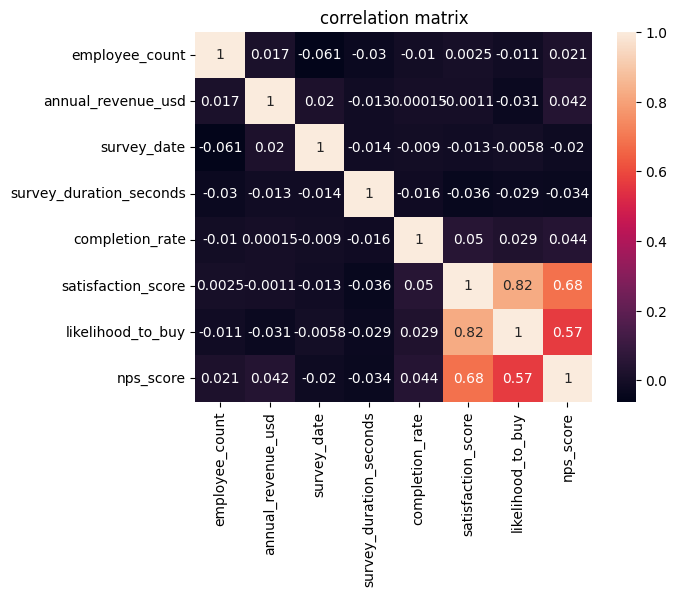

In [38]:
sns.heatmap(df[['employee_count', 'annual_revenue_usd', 'survey_date',
       'survey_duration_seconds', 'completion_rate', 'satisfaction_score',
       'likelihood_to_buy', 'nps_score']].corr(), annot = True)
plt.rcParams["figure.figsize"] = (35,10)
plt.title('correlation matrix')
plt.show()

There is a strong positive correlation between: 'satisfaction_score' and 'likelihood_to_buy' ~0.82,
                                                'nps_score' and 'satisfaction_score' ~0.68,
                                                'likelihood_to_buy' and 'nps_score' ~0.57 (less strong).
Also the correlations ~0 are normal because there is no direct relationship between them.

These results proves to a great extent the validation of the dataset.

### BOXPLOT (for outliers)

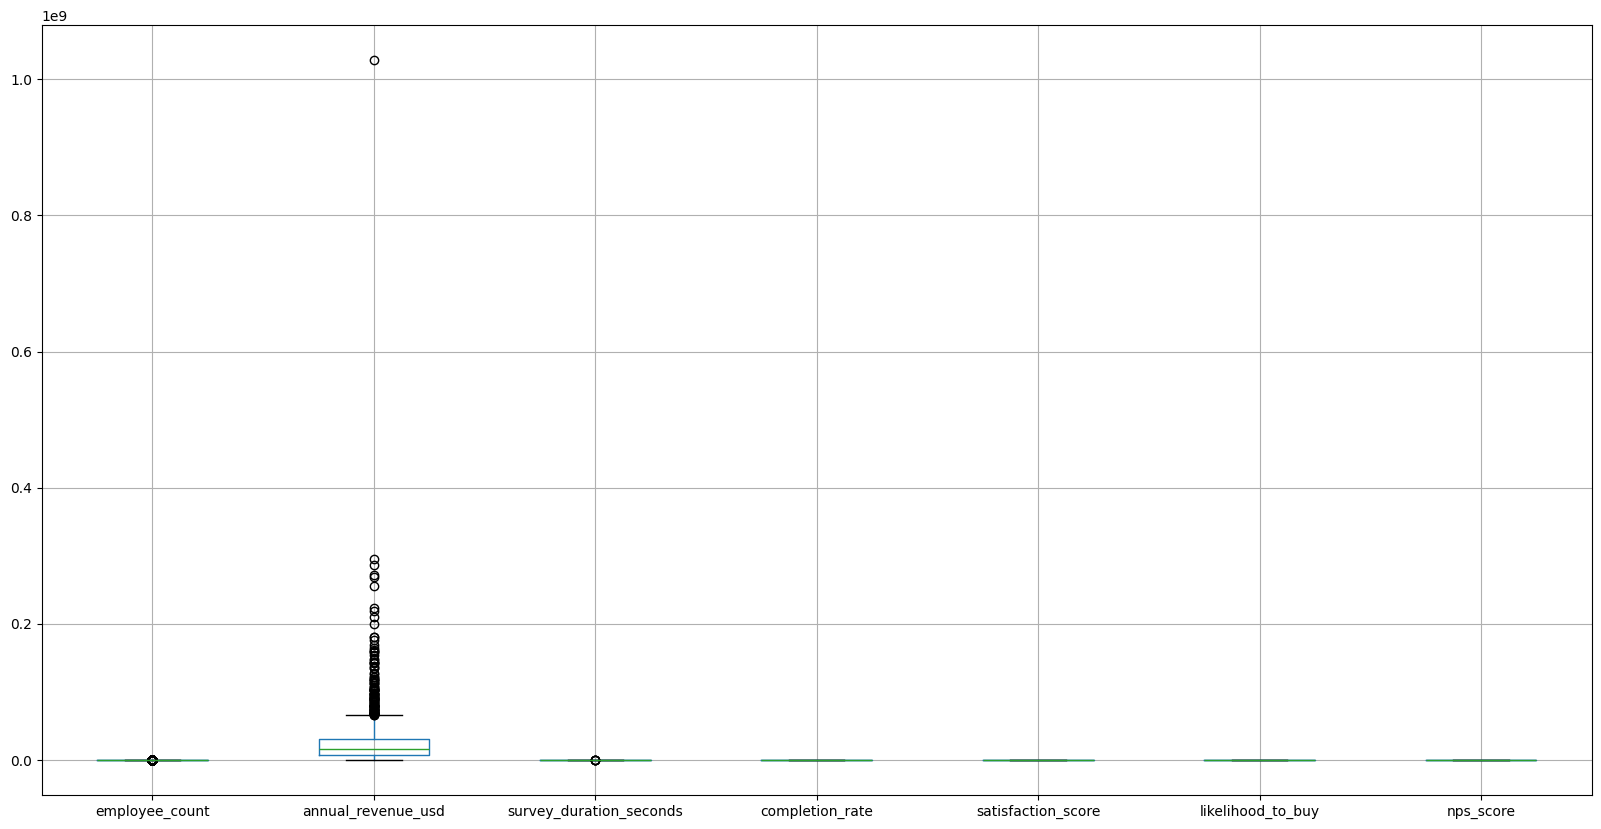

In [39]:
df.boxplot(figsize=(20,10))

plt.show()

In [40]:
df["annual_revenue_usd"].max()

np.int64(1028050477)

A company having annual revenue higher than 1 trillion $ is not possible.

### REMOVE THE OUTLIER

In [41]:
df = df.drop(df["annual_revenue_usd"].idxmax())

In [42]:
df["annual_revenue_usd"] = pd.to_numeric(df["annual_revenue_usd"], errors = 'coerce')

### BAR PLOT WITH THE RESPONSES

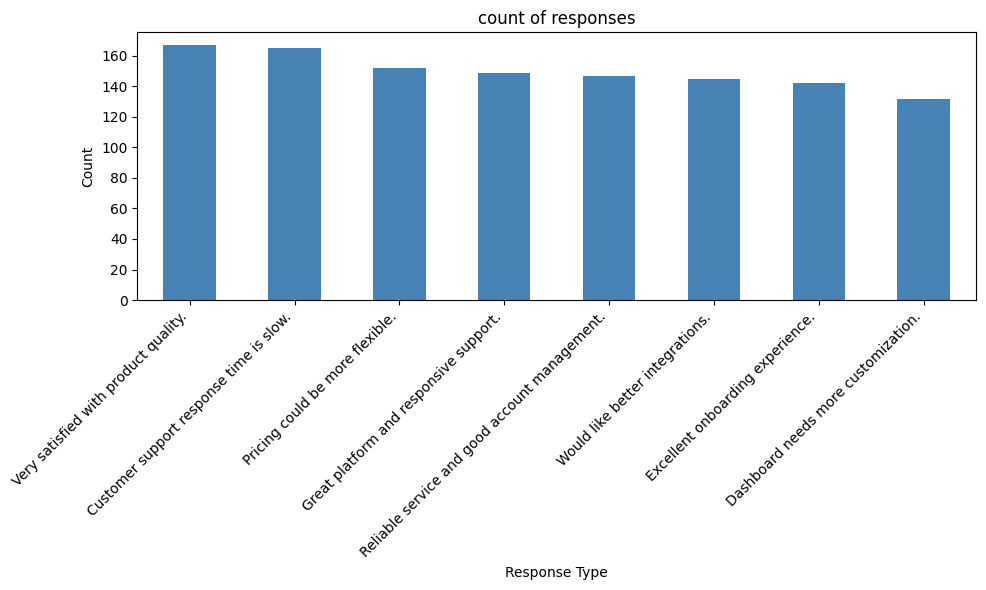

In [43]:
text_count = df['free_text_response'].value_counts()
plt.figure(figsize=(10, 6))
text_count.plot(kind='bar', color='steelblue')
plt.title('count of responses')
plt.xlabel('Response Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

The majority of the text responses seems to be the 'Very satisfied with product quality' response (160+ counts). 

However, the second and third most popular answers indicated that the customers were complaining about the slow response time and that the price could be more flexible

### GROUPING "free_text_response" WITH "satisfaction_score" AND "likelihood_to_buy" COLUMNS

In [44]:
pd.DataFrame(df.groupby('free_text_response')['satisfaction_score'].mean().sort_values(ascending = False))

,satisfaction_score
free_text_response,
Would like better integrations.,6.686207
Excellent onboarding experience.,6.679577
Reliable service and good account management.,6.663265
Customer support response time is slow.,6.454545
Pricing could be more flexible.,6.355263
Very satisfied with product quality.,6.329341
Dashboard needs more customization.,6.291667
Great platform and responsive support.,6.275168


In [45]:
pd.DataFrame(df.groupby('free_text_response')['likelihood_to_buy'].mean().sort_values(ascending = False))

,likelihood_to_buy
free_text_response,
Would like better integrations.,6.668966
Excellent onboarding experience.,6.661972
Reliable service and good account management.,6.517007
Pricing could be more flexible.,6.394737
Customer support response time is slow.,6.393939
Dashboard needs more customization.,6.356061
Very satisfied with product quality.,6.281437
Great platform and responsive support.,5.939597


Both satisfaction_score and likelihood_to_buy columns have similar rankings based on the free_text_response column. The paradox is that the text 'Great platform and responsive support' has lower satisfaction_score and likelihood_to_buy means. To conclude positive texts are not always compatible with high satisfaction scores 

### GROUPING "industry" WITH "annual_revenue_usd" AND "satisfaction_score" COLUMNS

In [46]:
pd.DataFrame(df.groupby('industry')['annual_revenue_usd'].mean().sort_values(ascending = False))

,annual_revenue_usd
industry,
Energy,3.140499e+07
Retail,2.925425e+07
Telecommunications,2.906449e+07
Finance,2.808759e+07
Consulting,2.791990e+07
Technology,2.694211e+07
Manufacturing,2.483286e+07
Healthcare,2.347515e+07
Unknown,2.263501e+07


In [47]:
pd.DataFrame(df.groupby('industry')['satisfaction_score'].mean().sort_values(ascending = False))

,satisfaction_score
industry,
Manufacturing,6.722222
Retail,6.525547
Healthcare,6.486577
Finance,6.473333
Technology,6.459184
Consulting,6.457143
Energy,6.358209
Telecommunications,6.321429
Unknown,6.240000


The top 3 industries with the highest satisfactions score are: Manufacturing(6.7), Finance(6.5), Retail(6.5). Also the means of the satisfaction score are between 6-7 and generally above 6. However the industries with higher revenue are tend to have lower satisfaction score. We assume that the greater the revenue in an industry, the greater the industry's demands.

### SUSPICIOUS RESPONCE DETECTION

In [48]:
df['survey_duration_seconds'].quantile(0.05)

np.float64(29.900000000000006)

In [49]:
df.loc[df['survey_duration_seconds'] < df['survey_duration_seconds'].quantile(0.05)].count()

respondent_id              60
company_name               60
industry                   60
company_size               60
employee_count             60
country                    60
annual_revenue_usd         60
survey_date                60
survey_duration_seconds    60
completion_rate            60
satisfaction_score         60
likelihood_to_buy          60
nps_score                  60
free_text_response         60
dtype: int64

5% (60) of the responses are unusually quick. This may indicate to unreliable answers

### SAME ANSWERS IN MULTIPLE DIFFERENT COLUMNS

In [50]:
df.loc[(df['satisfaction_score'] == df['likelihood_to_buy']) & (df['satisfaction_score'] == df['nps_score'])].count()

respondent_id              64
company_name               64
industry                   64
company_size               64
employee_count             64
country                    64
annual_revenue_usd         64
survey_date                64
survey_duration_seconds    64
completion_rate            64
satisfaction_score         64
likelihood_to_buy          64
nps_score                  64
free_text_response         64
dtype: int64

5.3% (64) of the companies have given the same answers to multiple columns. This may be due to an automation tool. 

### DETECTION OF INCOSISTENT RESPONSES

In [61]:
len(df.loc[(abs(df['satisfaction_score'] - df['likelihood_to_buy']) >= 4)])

2

In [60]:
len(df.loc[(abs(df['satisfaction_score'] - df['nps_score']) >= 4)])

0

In [67]:
len(df.loc[(abs(df['nps_score'] - df['likelihood_to_buy']) >= 5)])

48

2 rows are having a marginal incosistent responses between satisfaction score and likelihood to buy 

0 rows are having a marginal incosistent responses between satisfaction score and nps_score 

48 rows are having a marginal incosistent responses between satisfaction score and likelihood to buy


Those results are reasonable because satisfaction_score and likelihood_to_buy are less strongly correlative.

### COMPLETION RATE INSIGHT

In [52]:
df['completion_rate'].mean()

np.float64(0.8279149291075897)

completion rate is above 80%. The dataset is not perfect but it's quite reliable

# Regression model

In [68]:
df['satisfaction_log'] = np.log(df['satisfaction_score'])

In [53]:
df.columns

Index(['respondent_id', 'company_name', 'industry', 'company_size',
       'employee_count', 'country', 'annual_revenue_usd', 'survey_date',
       'survey_duration_seconds', 'completion_rate', 'satisfaction_score',
       'likelihood_to_buy', 'nps_score', 'free_text_response'],
      dtype='object')

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

X = pd.get_dummies(df[['annual_revenue_usd', 'survey_duration_seconds', 'completion_rate',
                        'likelihood_to_buy', 'nps_score', 'industry']],
                   columns=['industry'],
                   drop_first=True)

y = df['satisfaction_score']

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled_df = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

# statsmodels results
X_with_const = sm.add_constant(X_scaled_df)
model_stats = sm.OLS(y, X_with_const).fit()
print(model_stats.summary())

# model 
mdl = LinearRegression()
mdl.fit(X_scaled, y)

# predictions
y_pred = mdl.predict(X_scaled)

                            OLS Regression Results                            
Dep. Variable:     satisfaction_score   R-squared:                       0.748
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     270.4
Date:                Fri, 29 May 2026   Prob (F-statistic):               0.00
Time:                        17:45:19   Log-Likelihood:                -1665.9
No. Observations:                1199   AIC:                             3360.
Df Residuals:                    1185   BIC:                             3431.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                  coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------
const             

In [55]:
# Test for heteroskedasity
from statsmodels.stats.diagnostic import het_breuschpagan

bp_test = het_breuschpagan(
    model_stats.resid,
    model_stats.model.exog
)

labels = [
    "LM Statistic",
    "LM p-value",
    "F Statistic",
    "F p-value"
]

for name, value in zip(labels, bp_test):
    print(f"{name}: {value}")

LM Statistic: 6.48310522031837
LM p-value: 0.9267923797566786
F Statistic: 0.4955569002326596
F p-value: 0.9280351119245207


The OLS regression model demonstrates strong performance with an R-squared of 0.748, 
with likelihood to buy (β = 1.24, p < 0.001) and NPS score (β = 0.61, p < 0.001) 
as the primary predictors of satisfaction. The Breusch-Pagan test (p = 0.927) confirms 
the absence of heteroscedasticity, and diagnostic tests reveal no autocorrelation or 
multicollinearity issues. While the Jarque-Bera test flags non-normality in residuals, 
this is expected with large sample sizes (N = 1,199), where minor deviations become 
statistically detectable without affecting model reliability. Also the assumption that
the industries with higher revenue are tend to have lower satisfaction score is not proven
by our model BUT manufacturing industry showed a modest but significant positive effect
(the customers in this field shows 0.078 bigger satisfaction).

# EXCEL FILE

In [73]:
df.to_excel('B2B_data.xlsx', sheet_name = 'Data', index = False)